#  Library imports

In [309]:
import os
import warnings
warnings.filterwarnings('ignore')

import dask.dataframe as dd
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, auc, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier, cv, metrics, Pool
from catboost.utils import create_cd, get_roc_curve, get_fpr_curve, get_fnr_curve, select_threshold, get_confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

# Loading and processing data in Dask

In [4]:
os.getcwd()
file_path = os.path.abspath('parquets')
df = dd.read_parquet(file_path)

## Preparing functions for feature engineering

In [6]:
# Dask will compute this "lazily" (in chunks) without loading everything into RAM at once

In [7]:
# This part will go through 5 deliquency buckets & calculate the maximum delinquency state.
# The hierarchy of overdue periods: <5d → 5-30d → 30-60d → 60-90d → 90d+

def calculate_max_debt(partition):
    
    # This part runs inside each partition as a standard Pandas/NumPy operation
    conditions = [
        (partition['is_zero_loans90'] == 0),
        (partition['is_zero_loans6090'] == 0),
        (partition['is_zero_loans3060'] == 0),
        (partition['is_zero_loans530'] == 0),
        (partition['is_zero_loans5'] == 0)
    ]
    choices = [180, 90, 60, 30, 5]
    partition['max_bad_debt'] = np.select(conditions, choices, default=0)
    return partition

df = df.map_partitions(calculate_max_debt)

In [8]:
def paym_features_extrems (df):
    df_copy = df.copy()
    paym_features = [col for col in df_copy.columns if 'enc_paym_' in col]
    
    # Searching for the min and max values across rows (axis=1)
    df_copy['enc_min'] = df_copy[paym_features].min(axis=1)
    df_copy['enc_max'] = df_copy[paym_features].max(axis=1)

    return df_copy

df_copy = paym_features_extrems(df)

def paym_features_counts (df):
    df_copy = df.copy()
    paym_features = [col for col in df_copy.columns if 'enc_paym_' in col]

    # Counting where values equal 0,1,2,3,4 and sum across rows (axis=1)
    df_copy['Count_Zeros'] = (df_copy[paym_features] == 0).sum(axis=1)
    df_copy['Count_Ones'] = (df_copy[paym_features] == 1).sum(axis=1)
    df_copy['Count_Twos'] = (df_copy[paym_features] == 2).sum(axis=1)
    df_copy['Count_Threes'] = (df_copy[paym_features] == 3).sum(axis=1)
    df_copy['Count_Fours'] = (df_copy[paym_features] == 4).sum(axis=1)

    return df_copy

df_copy2 = paym_features_counts(df_copy)

In [9]:
# Aggregating features by 'id'

def aggregate_features(df):
    df_copy = df.copy()
    agg_spec = {}

    agg_spec['is_zero_util'] = ['mean'] # Share of fully repaid loans
    agg_spec['is_zero_over2limit'] = ['mean'] # Share of loans overdue
    agg_spec['is_zero_loans90'] = ['min'] # Critical delinquency marker
    agg_spec['max_bad_debt'] = ['max'] # The maximum delinquency state
    agg_spec['pre_since_opened'] = ['max'] # Age of the oldest loan
    agg_spec['pre_util'] = ['min', 'max'] # Limit utilization dynamics
    agg_spec['enc_loans_credit_type'] = ['min', 'max'] # Loans type diversity
    agg_spec['pre_loans_credit_cost_rate'] = ['mean'] # Average cost of debt
    agg_spec['pre_pterm'] = ['min', 'max'] # Scheduled closing dates 
    agg_spec['pre_fterm'] = ['min', 'max'] # Factual closing dates
    agg_spec['pre_since_confirmed'] = ['min', 'max'] # The relevance of data
    agg_spec['pre_till_pclose'] = ['min', 'max'] # Scheduled time buffer until closure
    agg_spec['pre_till_fclose'] = ['min', 'max'] # Factual time buffer until closure
    agg_spec['pre_loans_credit_limit'] = ['sum'] # Total limit
    agg_spec['pre_maxover2limit'] = ['min', 'max'] #  Limit discipline
    agg_spec['enc_min'] = ['min'] # Behavioral counters
    agg_spec['enc_max'] = ['max'] # Behavioral counters
    agg_spec['Count_Zeros'] = ['count'] # Behavioral counters
    agg_spec['Count_Ones'] = ['count'] # Behavioral counters
    agg_spec['Count_Twos'] = ['count'] # Behavioral counters
    agg_spec['Count_Threes'] = ['count'] # Behavioral counters
    agg_spec['Count_Fours'] = ['count'] # Behavioral counters

    df_copy = df_copy.groupby(['id']).agg(agg_spec)

    df_copy.columns = [f'{col}_{stat}' for col, stat in df_copy.columns]
    return df_copy

df_copy3 =aggregate_features(df_copy2)

In [10]:
df_copy3 = df_copy3.compute()
df_copy3['id'] = df_copy3.index

# Merging features with the target variable

In [12]:
features = df_copy3.reset_index(drop=True)
flags = pd.read_csv('train_target.csv')

In [13]:
def merging (features, flags):
    df = pd.merge(flags, features, how = 'left')

    # Removing delinquencies over 90 days that aren't yet flagged as defaults, as this contradicts the problem constraints
    df = df.drop(df[(df.is_zero_loans90_min == 0) & (df.flag == 0)].index)
    df = df.drop(columns=['id'])
    return df

df_final = merging(features, flags)
df_final

,flag,is_zero_util_mean,is_zero_over2limit_mean,is_zero_loans90_min,max_bad_debt_max,pre_since_opened_max,pre_util_min,pre_util_max,enc_loans_credit_type_min,enc_loans_credit_type_max,...,pre_loans_credit_limit_sum,pre_maxover2limit_min,pre_maxover2limit_max,enc_min_min,enc_max_max,Count_Zeros_count,Count_Ones_count,Count_Twos_count,Count_Threes_count,Count_Fours_count
0,0,0.600000,0.900000,1,5,18,1,16,1,4,...,96,4,17,0,4,10,10,10,10,10
2,0,0.333333,1.000000,1,90,13,3,16,3,4,...,5,11,17,0,4,3,3,3,3,3
3,0,0.533333,0.933333,1,0,18,2,18,1,5,...,148,4,17,0,4,15,15,15,15,15
4,0,1.000000,1.000000,1,0,12,16,16,3,3,...,12,17,17,3,4,1,1,1,1,1
5,0,0.750000,0.750000,1,30,19,7,16,1,4,...,47,0,17,0,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999994,0,0.750000,0.833333,1,30,17,6,16,0,4,...,83,4,17,0,4,12,12,12,12,12
2999995,0,0.727273,1.000000,1,30,19,10,16,3,7,...,81,17,17,0,4,11,11,11,11,11
2999996,0,0.692308,0.846154,1,60,16,4,16,3,7,...,151,4,17,0,4,13,13,13,13,13
2999997,0,0.600000,1.000000,1,30,17,4,16,3,4,...,70,3,17,0,4,10,10,10,10,10


## Splitting the Data into Features and Target

In [16]:
X = df_final.drop('flag', axis=1)
y = df_final.flag
# Preparing train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8, random_state=42)

# Modeling

## Logistic Regression

In [18]:
# Initializing the model
model1 = LogisticRegression(penalty = 'l1', solver = 'saga', class_weight = 'balanced')

In [19]:
model1.fit(X_train,y_train)
pred1 = model1.predict_proba(X_test)[:,1]
score1 = roc_auc_score(y_test,pred1)
print(f"Logistic Regression ROC-AUC: {score1:.4f}")

Logistic Regression ROC-AUC: 0.7310


In [20]:
# # Defining the parameters grid
# param_grid1 = {
#     "penalty": ['l1', 'l2'],
#     "solver": ['saga'],
#     "class_weight": ['balanced', None], # Search between balanced and default
#     "C": [0.01, 0.1, 1.0, 10.0]         # Critical for Logistic Regression
# }

# randomized_search1 = RandomizedSearchCV(
#    estimator=model1,
#    param_distributions=param_grid1,
#    n_iter=10,
#    scoring='roc_auc',
#    verbose=10,
#    n_jobs=-1 # Using -1 to utilize all cores
# )

# # Performing parameter grid search / tuning
# randomized_search1.fit(X_train, y_train)

# # Outputting the best parameters
# best_params1 = randomized_search1.best_params_
# best_params1

In [47]:
best_params1 = {'solver': 'saga', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.01}

In [49]:
model1_tuned = LogisticRegression(**best_params1)
model1_tuned.fit(X_train,y_train)
pred1 = model1_tuned.predict_proba(X_test)[:,1]
score1 = roc_auc_score(y_test,pred1)
print(f"Logistic Regression ROC-AUC: {score1:.4f}")

Logistic Regression ROC-AUC: 0.7310


## Decision Tree

In [51]:
model2 = DecisionTreeClassifier(min_samples_split = 50, max_depth=10)

In [52]:
model2.fit(X_train, y_train)
pred2 = model2.predict_proba(X_test)[:,1]
score2 = roc_auc_score(y_test,pred2)
print(f"Decision Tree ROC-AUC: {score2:.4f}")

Decision Tree ROC-AUC: 0.7491


In [53]:
# # Defining the parameters grid
# param_grid2 = {"criterion": ["gini", "entropy"],
#     "max_depth": [3, 5, 10, None],          # None allows the tree to grow deep
#     "min_samples_leaf": [1, 5, 10, 20],     # Prevents nodes with too few samples
#     "class_weight": ["balanced", None]}

# randomized_search2 = RandomizedSearchCV(
#    estimator=model2,
#    param_distributions=param_grid2,
#    n_iter=10,
#    scoring='roc_auc',
#    verbose=10,
#    n_jobs=-1 # Using -1 to utilize all cores
# )

# # Performing parameter grid search / tuning
# randomized_search2.fit(X_train, y_train)

# # Outputting the best parameters
# best_params2 = randomized_search2.best_params_
# best_params2

In [54]:
best_params2 = {'min_samples_leaf': 1,
 'max_depth': 10,
 'criterion': 'entropy',
 'class_weight': None}

In [55]:
model2_tuned = DecisionTreeClassifier(**best_params2)
model2_tuned.fit(X_train,y_train)
pred2 = model2_tuned.predict_proba(X_test)[:,1]
score2 = roc_auc_score(y_test,pred2)
print(f"Decision Tree ROC-AUC: {score2:.4f}")

Decision Tree ROC-AUC: 0.7501


## Random Forest

In [57]:
model3 = RandomForestClassifier(
    n_estimators=100,      # Number of trees (100-500 is usually sufficient)
    max_depth=10,          # Limiting depth to avoid overfitting
    min_samples_leaf=20,   # Minimum samples per leaf (helps prevent overfitting)
    max_features = 'sqrt', # Number of features to consider at each split
    random_state=42,       # For reproducibility
    class_weight='balanced_subsample',
    n_jobs=-1              # Use all CPU cores for acceleration
)

In [58]:
model3.fit(X_train,y_train)
pred3 = model3.predict_proba(X_test)[:,1]
score3 = roc_auc_score(y_test,pred3)
print(f"Tuned Random Forest ROC-AUC: {score3:.4f}")

Tuned Random Forest ROC-AUC: 0.7617


In [59]:
# # Defining the parameters grid
# param_grid3 = {
#     "n_estimators": [100],                  # Number of trees in the forest
#     "max_depth": [3, 5, 10],                # Usually best to keep shallow for credit scoring
#     "min_samples_leaf": [5, 10, 20],        # Helps generalize better
#     "max_features": ["sqrt", "log2"],       # Number of features to consider at each split
#     "class_weight": ["balanced", "balanced_subsample", None] # This is a specific Random Forest setting where weights are calculated for each tree based on the bootstrap sample. 
#                                                              # It's often better for imbalanced data than the standard balanced
# }

# randomized_search3 = RandomizedSearchCV(
#    estimator=model3,
#    param_distributions=param_grid3,
#    n_iter=10,
#    scoring='roc_auc',
#    verbose=2,
#    n_jobs=-1 # Using -1 to utilize all cores
# )

# # Performing parameter grid search / tuning
# randomized_search3.fit(X_train, y_train)

# # Outputting the best parameters
# best_params3 = randomized_search3.best_params_
# best_params3

In [60]:
best_params3 = {'n_estimators': 100,
 'min_samples_leaf': 20,
 'max_features': 'sqrt',
 'max_depth': 10,
 'class_weight': 'balanced'}

In [61]:
model3_tuned = RandomForestClassifier(**best_params3)
model3_tuned.fit(X_train,y_train)
pred3 = model3_tuned.predict_proba(X_test)[:,1]
score3 = roc_auc_score(y_test,pred3)
print(f"Tuned Random Forest ROC-AUC: {score3:.4f}")

Tuned Random Forest ROC-AUC: 0.7618


## Catboost Classifier. Pipeline.

In [63]:
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
train_pool = Pool(X_train, y_train, cat_features=cat_features)


class CustomCatBoostClassifier(CatBoostClassifier):
    def fit(self, X, y=None, **fit_params):
        cat_features = X.select_dtypes(include=['object']).columns.tolist()
 
        return super().fit(X, y=y, cat_features=cat_features, **fit_params) 

In [64]:
def drop_empty_columns(df): # Drop columns with a high percentage of missing values (>25%)
    df = df.copy()
    for key, value in dict(zip(df.columns, round(((df.isna().sum()/len(df))*100),2))).items():
        if value > 25:
            df.apply(lambda x: x.drop(columns = [key]))
    return df

def fill_out_columns(df):
    df = df.copy()
    for column in df:
        if df[column].isna().sum() > 0:
            df[column] = df[column].fillna(df[column].mode()[0])
    return df

def drop_features(df):
    df = df.copy()
    features_to_drop = [
    ]
    df = df.drop(features_to_drop, axis=1)
    return df

In [177]:
model = CustomCatBoostClassifier(eval_metric ='AUC',
                                 loss_function = "Logloss",
                                 iterations = 1000,
                                 early_stopping_rounds=50,
                                 random_seed = 42,
                                 learning_rate = 0.05,
                                 depth = 3,
                                 verbose = False)

final_preprocessor = Pipeline(steps=[
    ('step_1', FunctionTransformer(drop_empty_columns)),
    ('step_2', FunctionTransformer(fill_out_columns)),
    ('step_3', FunctionTransformer(drop_features)),
    ('step_4', model)
])

In [179]:
final_preprocessor.fit(X_train, y_train)
score4 = cross_val_score(final_preprocessor, X_test, y_test, cv=4, scoring='roc_auc')
print(f"CatBoost (Best Cross-Val) ROC-AUC: {score4.mean():.4f}")

CatBoost (Best Cross-Val) ROC-AUC: 0.7732


### Checking the Feature Importance

In [117]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,max_bad_debt_max,32.637267
1,is_zero_loans90_min,31.520651
2,pre_util_min,7.479625
3,enc_loans_credit_type_min,5.996431
4,is_zero_util_mean,4.246147
5,pre_since_opened_max,3.322374
6,enc_loans_credit_type_max,2.726718
7,pre_util_max,1.600497
8,pre_till_fclose_min,1.295863
9,pre_maxover2limit_min,1.201755


### Selecting/validating best parameters

In [120]:
# param_grid = {
#     "step_4__learning_rate": [0.01, 0.05, 0.1],
#     "step_4__depth": [1, 3, 6]
# }

# randomized_search = RandomizedSearchCV(
#    estimator=final_preprocessor,
#    param_distributions=param_grid,
#    n_iter=10,
#    scoring='roc_auc',
#    verbose=False,
#    n_jobs=1
# )

# # Performing parameter grid search / tuning
# randomized_search.fit(X_train, y_train)

# # Outputting the best parameters
# best_params = randomized_search.best_params_
# best_params

* Limitations of Random Search: With a relatively small number of iterations, Random Search may fail to converge on the true global optimum.
* Suboptimal Results: Consequently, the "best" parameters identified may only represent a local peak rather than the best possible configuration.

In [173]:
model_tuned = CustomCatBoostClassifier(eval_metric ='AUC',
                                       loss_function = "Logloss",
                                       iterations = 1000,
                                       early_stopping_rounds=50,
                                       random_seed = 42,
                                       learning_rate = 0.15,
                                       depth = 3,
                                       verbose = False)

final_preprocessor_tuned = Pipeline(steps=[
    ('step_1', FunctionTransformer(drop_empty_columns)),
    ('step_2', FunctionTransformer(fill_out_columns)),
    ('step_3', FunctionTransformer(drop_features)),
    ('step_4', model_tuned)
])

In [175]:
final_preprocessor_tuned.fit(X_train, y_train)
score4 = cross_val_score(final_preprocessor_tuned, X_test, y_test, cv=4, scoring='roc_auc')
print(f"CatBoost (Best Cross-Val) ROC-AUC: {score4.mean():.4f}")

CatBoost (Best Cross-Val) ROC-AUC: 0.7744


ROC-AUC = 0.7744 means that in 77% of cases, if you pick one random defaulter and one random good customer, the defaulter will have a higher 'suspicion rating' (predicted probability)

# Interpreting The Result

## ROC-AUC curve

ROC-AUC is not dependent on the threshold.
* Unlike Accuracy or F1-score that we'll be looking at later on, the ROC-AUC metric evaluates the model across all possible thresholds simultaneously (from 0 to 1). 
* It measures how effectively the model ranks customers: specifically, whether actual defaulters appear higher on the 'suspicion' list than good customers.
* If the ROC-AUC is 0.77, it means that in 77% of cases, if we were to pick one random defaulter and one random good customer, the defaulter would have a higher 'suspicion rating.'
* Ultimately, ROC-AUC is an assessment of the quality of the 'ranking' itself, rather than an assessment of a specific decision to 'approve or deny a loan.'

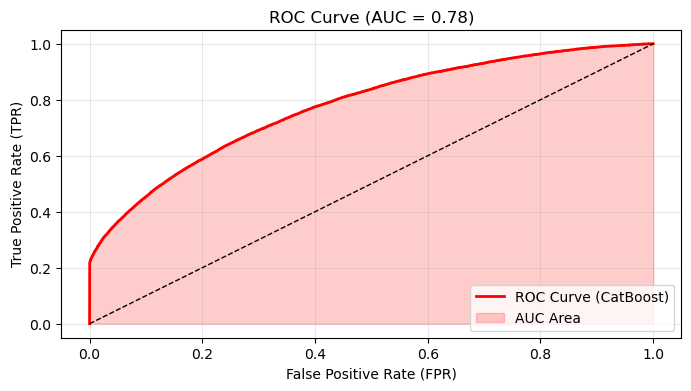

In [327]:
y_score = final_preprocessor_tuned.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score) 
roc_auc = auc(fpr, tpr) # This is a single "snapshot" of performance on the specific X_test set. 
                        # It differs from cross_val_score because that final model was trained on 
                        # 100% of the training data, and cross_val_score averaged 4 models 
                        # that each only saw 75% of the data.

plt.figure(figsize=(8, 4)) 
plt.plot(fpr, tpr, label='ROC Curve (CatBoost)', color='red', lw=2)
plt.fill_between(fpr, tpr, color='red', alpha=0.2, label='AUC Area')
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

The area under the ROC curve shows:
* **Probability of Correct Ranking:** It represents the probability that the model will rank a randomly chosen positive instance (defaulter) higher than a randomly chosen negative instance (good customer).
* **Model Discriminative Power:** It measures how well the model separates the two classes.
- 1.0: Perfect model (no overlap between classes).
- 0.7–0.8: Respectable/Good performance.
- 0.5: No better than a coin flip (random guessing).
* **Threshold Invariance:** Since it covers all thresholds, it tells us the quality of the model's probabilities regardless of whether we are strict or lenient with our classification.

## Threshold = 0.5 (by default)

#### The Confusion Matrix

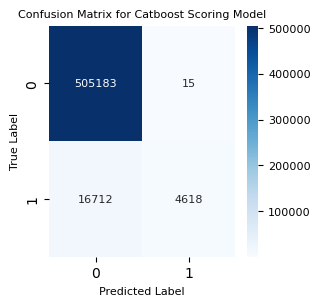

In [186]:
test_pool = Pool(data = X_test, label=y_test)
cm = get_confusion_matrix(model_tuned, test_pool)

plt.figure(figsize=(3,3))
ax = sns.heatmap(cm, annot = True, fmt = '.0f', cmap = 'Blues', annot_kws={"size": 8})
plt.xlabel('Predicted Label', fontsize=8)
plt.ylabel('True Label', fontsize=8)
plt.title('Confusion Matrix for Catboost Scoring Model', fontsize=8)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8) # Set the font size for the colorbar scale here
plt.show()

This table shows exactly where the model "tripped up."
* Top-Left (True Negative): Clients who did not default, and the model correctly predicted they wouldn't. (Good for business).
* Bottom-Right (True Positive): Clients who did default, and the model caught them. (The main goal).
* Top-Right (Type I Error / False Positive): "False Alarms." The model said they would default, but they were actually good payers. Business impact: The loss of a potential customer.
* Bottom-Left (Type II Error / False Negative): The most dangerous error. The model said they were "safe," but they actually defaulted. Business impact: The bank loses money.

This gives three key metrics for both "0" (non-default) and "1" (default):
* Precision (Accuracy of "Yes"): When the model says "this person will default," how often is it right? If Precision is 0.80, then 80% of our "default alarms" are real.
* Recall (Sensitivity): Out of all the people who actually defaulted, what percentage did the model catch? If Recall is 0.60, you found 60% of the bad debtors, but 40% "escaped."
* F1-Score: The "middle ground" between Precision and Recall. It’s the best metric if we want a single number to describe the quality of a specific class.
* Support: Simply the number of actual samples in each class (how many 0s and 1s were in your test set).

#### The Classification Report

In [181]:
y_pred = final_preprocessor_tuned.predict(X_test) # the code uses a default threshold of 0.5.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    505198
           1       1.00      0.22      0.36     21330

    accuracy                           0.97    526528
   macro avg       0.98      0.61      0.67    526528
weighted avg       0.97      0.97      0.96    526528



The Good News: High Precision
* Every single person the model flagged as a defaulter, actually defaulted. The bank will never turn away a good client by mistake.

The Bad News: Very Low Recall
* The model is only catching 22% of actual defaults.

The model is conservative; while it doesn't give many false alarms (high Precision), it misses some risky clients (low Recall).

## Custom threshold (0.05)

These aren't just 0s and 1s; they are probabilities.
In credit scoring, we don't just want to know "yes/no." We want to know the risk level.
* A score of 0.95 is a high-risk client.
* A score of 0.05 is a very safe client.

Why it matters: The bank can decide where to "draw the line" (the threshold). For example, only give loans to people with a score lower than 0.05.

#### The Confusion Matrix

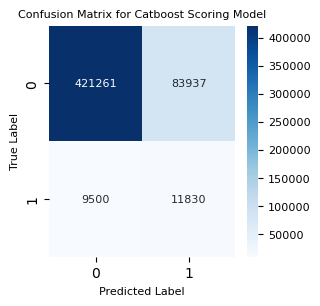

In [209]:
y_pred_custom = (final_preprocessor_tuned.predict_proba(X_test)[:, 1] > 0.05).astype(int)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(3,3))
ax = sns.heatmap(cm, annot = True, fmt = '.0f', cmap = 'Blues', annot_kws={"size": 8})
plt.xlabel('Predicted Label', fontsize=8)
plt.ylabel('True Label', fontsize=8)
plt.title('Confusion Matrix for Catboost Scoring Model', fontsize=8)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8) # Set the font size for the colorbar scale here
plt.show()

#### Predict proba

In [193]:
y_pred_new = (final_preprocessor_tuned.predict_proba(X_test)[:, 1] > 0.05).astype(int) # drastically changing how "suspicious" the model is
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90    505198
           1       0.12      0.55      0.20     21330

    accuracy                           0.82    526528
   macro avg       0.55      0.69      0.55    526528
weighted avg       0.94      0.82      0.87    526528



For a bank, a report with a 0.05 threshold (or another low number) is almost always more important. 
It is more profitable for the bank to make a mistake and deny a loan to a good customer (losing interest profit) than to grant a loan to a defaulter and lose the money.

# The winning model

The CatBoost model is recommended for deployment because:

* **Native Categorical Support:** It handles categorical features internally, eliminating the need for complex manual preprocessing (like One-Hot Encoding).
* **Superior Performance:** It achieved the highest ROC-AUC (0.77) and Gini coefficient (0.54) among all tested models.

Alternative Consideration: Logistic Regression

* **Interpretability:** LogReg remains the most transparent and interpretable model for stakeholders.
* **Selection Logic:** Had the Logistic Regression model shown a comparable ROC-AUC, it would have been the preferred choice due to its simplicity. However, the performance gap justifies the use of the more complex CatBoost model.

# Saving to a pickle file

In [155]:
# import json
# from catboost import *

In [156]:
# with open('data/data.json') as fin:
#         form = json.load(fin)
#         df = pd.DataFrame.from_dict([form])
#         cat_features = df.select_dtypes(include=['object']).columns.tolist()
#         pool = Pool(data = df, cat_features = cat_features)
#         y = model_tuned.predict(pool)
#         print(f"{form['client_id']}: {y[0]}")